# Cox Regression Penalized

### Imports

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

# Clinical Data
df = pd.read_csv("./data/X_train/clinical_train.csv")
df_eval = pd.read_csv("./data/X_test/clinical_test.csv")

# Molecular Data
maf_df = pd.read_csv("./data/X_train/molecular_train.csv")
maf_eval = pd.read_csv("./data/X_test/molecular_test.csv")

target_df = pd.read_csv("./data/target_train.csv")

# TODO : Uncomment for test data ??
"""
target_df_test = pd.read_csv("./data/target_test.csv")
"""
# Preview the data
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


### Cleaning

In [4]:
# Drop rows where 'OS_YEARS' is NaN if conversion caused any issues
target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)


# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

OS_STATUS    float64
OS_YEARS     float64
dtype: object


0. Parsing functions

In [5]:
total_features = []
def parse_EFFECT():
    global df, df_eval, maf_df, maf_eval, total_features

    effect_vaf = maf_df.groupby(['ID', 'EFFECT'])['VAF'].max().unstack(fill_value=0)
    effect_vaf_eval = maf_eval.groupby(['ID', 'EFFECT'])['VAF'].max().unstack(fill_value=0)

    effect_vaf.columns = [f"EFFECT_{col}" for col in effect_vaf.columns]
    for col in effect_vaf.columns:
        if col not in effect_vaf_eval.columns:
            effect_vaf_eval[col] = 0
        else:
            effect_vaf_eval[col] = effect_vaf_eval[col]
    df = df.merge(effect_vaf.reset_index(), on='ID', how='left')
    df_eval = df_eval.merge(effect_vaf_eval.reset_index(), on='ID', how='left')
    total_features += list(effect_vaf.columns)
    print("Parsed EFFECT VAF features:", effect_vaf.columns.tolist())

def parse_PROTEIN_CHANGE(protein):
    protein = str(protein)

    if len(protein) == 0 or len(protein) == 1:
        return pd.NA
    
    try:
        protein = str(protein.split('.')[1])
    
    except IndexError:
        return pd.NA
    
    if protein == '?' or protein[0] == '*':
        return pd.NA
    
    else:
        return protein[0].lower()
    
def parse_REF(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_ALT(ref):
    ref = str(ref)
    if len(ref) == 0:
        return pd.NA
    elif ref[0] == '-':
        return pd.NA
    else:
        return ref[0]
    
def parse_CHR(chr):
    chr = str(chr)
    if chr not in ['1','2','3','4','5','6','7','8','9','10',
                   '11','12','13','14','15','16','17','18',
                   '19','20','21','22','X','Y']:
        return pd.NA
    else:
        return chr
    
def parse_GENE(gene):
    gene = str(gene)
    if len(gene) == 0:
        return pd.NA
    elif len(gene) < 4:
        return gene
    else:
        return gene[0:4]

import re
from collections import defaultdict

def parse_CYTO(iscn):
    global total_features
    iscn = str(iscn)
    iscn = iscn.upper()
    results = defaultdict(int)
    clones = iscn.replace(" ", "").split("/")
    for clone in clones:
        clone = clone.strip()

        # detect normal clone
        if re.match(r"46,[XY]{2}", clone.replace(" ", "")) and "+" and "-" not in clone:
            results["normal"] = True

        # extract +n or -n NOT followed by letters (exclude mar) only if n is in {1,...,21} or in [X,Y]
        numeric_changes = re.findall(r"([+-])(\d+|X|Y)(?=[,/ \]]|$)", clone)

        for sign, num in numeric_changes:
            if str(num) not in [str(i) for i in range(1, 22)] + ['X', 'Y']:
                continue
            key = f"{sign}{num}"
            results[key] = True

        del_add_changes = re.findall("(del\(\d+\)|add\(\d+\)", clone)
        for change in del_add_changes:
            key = f"change"
            results[key] = True
    total_features = total_features + results.keys
    return dict(results)

def parse_CYTO_weighted(iscn):
    """
    Extract numeric chromosome gains/losses from an ISCN karyotype string,
    ignoring +mar or +nmar patterns.
    """
    global total_features
    iscn = str(iscn)
    iscn = iscn.upper()
    results = defaultdict(int)
    clones = iscn.replace(" ", "").split("/")
    total_observations = 0

    for clone in clones:
        clone = clone.strip()

        # extract clone count [n] or [n/m]
        count_match = re.search(r"\[(\d+)", clone)
        count = int(count_match.group(1)) if count_match else 1
        total_observations += count

        # detect normal clone
        if re.match(r"46,[XY]{2}", clone.replace(" ", "")) and "+" and "-" not in clone:
            results["normal"] += count

        # extract +n or -n NOT followed by letters (exclude mar) only if n is in {1,...,21} or in [X,Y]
        numeric_changes = re.findall(r"([+-])(\d+|X|Y)(?=[,/ \]]|$)", clone)

        for sign, num in numeric_changes:
            if str(num) not in [str(i) for i in range(1, 22)] + ['X', 'Y']:
                continue
            key = f"{sign}{num}"
            results[key] += count
    # Normalize counts to proportions
    for key in results:
        results[key] = np.round(results[key] / total_observations, 2)
    total_features = total_features + results.keys
    return dict(results)

1. Extracting number of somatic mutations and cytogenetics parsing

In [6]:
# Step: Extract the number of somatic mutations per patient

# Merge with the training dataset and replace missing values in 'Nmut' with 0
if 'Nmut' not in df.columns:
    # Group by 'ID' and count the number of mutations (rows) per patient
    tmp = maf_df.groupby('ID').size().reset_index(name='Nmut')
    tmp_eval = maf_eval.groupby('ID').size().reset_index(name='Nmut')
    
    df = df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})
    df_eval = df_eval.merge(tmp_eval, on='ID', how='left').fillna({'Nmut': 0})

if '+X' not in df.columns:
    # Apply the parse_cytogenetics function to create a new column with parsed abnormalities
    cytogenetics_labels = ['+' + str(i) for i in range(1,22)] + ['-' + str(i) for i in range(1,22)] + ['normal'] + ['+X', '+Y', '-X', '-Y']

    df['CYTOGENETICS_ABNORMALITIES'] = df['CYTOGENETICS'].apply(parse_CYTO)
    df_eval['CYTOGENETICS_ABNORMALITIES'] = df_eval['CYTOGENETICS'].apply(parse_CYTO)

    # Expand the abnormalities into separate columns
    for label in cytogenetics_labels:
        df[f'{label}'] = df['CYTOGENETICS_ABNORMALITIES'].apply(lambda x: x.get(label, 0) if isinstance(x, dict) else 0)
        df_eval[f'{label}'] = df_eval['CYTOGENETICS_ABNORMALITIES'].apply(lambda x: x.get(label, 0) if isinstance(x, dict) else 0)

    for label in cytogenetics_labels:
        if df[f'{label}'].sum() == 0:
            df.drop(columns=[f'{label}'], inplace=True)
            df_eval.drop(columns=[f'{label}'], inplace=True)
        else:
            total_features.append(f'{label}') 

    # Drop the original 'CYTOGENETICS' and temporary columns
    df.drop(columns=['CYTOGENETICS', 'CYTOGENETICS_ABNORMALITIES'], inplace=True)
    df_eval.drop(columns=['CYTOGENETICS', 'CYTOGENETICS_ABNORMALITIES'], inplace=True)
    
df.head()

error: missing ), unterminated subpattern at position 0

2. One hot encoding 'GENE', 'EFFECT' and 2 first relevant characters of 'PROTEIN_CHANGE'

In [ ]:
def add_feature(features_list):
    global total_features, df, df_eval
    for feature in features_list:
        if feature != 'EFFECT':
            if feature in df.columns:
                print(f"Feature \'{feature}\' already exists. Skipping...")
                continue
            parse_function = globals().get(f'parse_{feature}')
            if parse_function:
                one_hot_encoded_feature = pd.get_dummies(maf_df[feature].apply(parse_function), prefix=feature)
                one_hot_encoded_eval = pd.get_dummies(maf_eval[feature].apply(parse_function), prefix=feature)
            else:
                raise ValueError(f"No function named 'parse_{feature}' found.")
            
            maf_df_one_hot_feature = pd.concat([maf_df[['ID']], one_hot_encoded_feature], axis=1)
            maf_eval_one_hot_feature = pd.concat([maf_eval[['ID']], one_hot_encoded_eval], axis=1)

            maf_df_feature_agg = maf_df_one_hot_feature.groupby('ID').max().reset_index()
            maf_eval_feature_agg = maf_eval_one_hot_feature.groupby('ID').max().reset_index()

            # Merge all new columns at once
            df = df.merge(maf_df_feature_agg.fillna(0), on='ID', how='left')
            df_eval = df_eval.merge(maf_eval_feature_agg.fillna(0), on='ID', how='left')
            total_features = total_features + list(maf_df_feature_agg.drop(columns=['ID']).columns)
        elif feature == 'EFFECT':
            parse_EFFECT()

add_feature(['GENE', 'PROTEIN_CHANGE', 'REF', 'ALT','EFFECT'])

Parsed EFFECT VAF features: ['EFFECT_2KB_upstream_variant', 'EFFECT_3_prime_UTR_variant', 'EFFECT_ITD', 'EFFECT_PTD', 'EFFECT_complex_change_in_transcript', 'EFFECT_frameshift_variant', 'EFFECT_inframe_codon_gain', 'EFFECT_inframe_codon_loss', 'EFFECT_inframe_variant', 'EFFECT_initiator_codon_change', 'EFFECT_non_synonymous_codon', 'EFFECT_splice_site_variant', 'EFFECT_stop_gained', 'EFFECT_stop_lost', 'EFFECT_stop_retained_variant', 'EFFECT_synonymous_codon']


### 3. Training

1. Selecting features and getting rid of rows with NaN values in training set

In [ ]:
# Select features and target columns
features = ['BM_BLAST', 'HB', 'PLT', 'ANC','WBC','MONOCYTES','Nmut']
total_features = total_features + features

# target features
target = ['OS_YEARS', 'OS_STATUS']

# Remove rows with missing feature values
df = df.merge(target_df[['ID', 'OS_YEARS', 'OS_STATUS']], on='ID', how='inner')
df = df.dropna()

# Build feature matrix and survival target
X = df[total_features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', df[target])
for col in X.columns:
    print(col)

BM_BLAST
HB
PLT
ANC
WBC
MONOCYTES
Nmut


In [ ]:
X_eval = df_eval['ID']
for col in list(X.columns):
    if col in list(df_eval.columns):
        X_eval = pd.DataFrame(X_eval).merge(df_eval[['ID', col]], on='ID', how='left')
    else:
        X_eval[col] = pd.NA
X_eval.drop(columns=['ID'], inplace=True)
X_eval.head()

,BM_BLAST,HB,PLT,ANC,WBC,MONOCYTES,Nmut
0,68.0,7.6,48.0,0.5865,3.45,NaN,4.0
1,35.0,10.0,32.0,1.2402,3.18,NaN,3.0
2,NaN,12.3,25.0,8.6800,12.40,NaN,3.0
3,61.0,8.0,44.0,2.0535,5.55,NaN,3.0
4,2.0,8.6,27.0,0.7381,1.21,NaN,3.0


2. Spliting dataset

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=41)
X_train.head()

NameError: name 'train_test_split' is not defined

3. Fitting Cox Ridge model

In [7]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxnetSurvivalAnalysis(l1_ratio=1, alpha_min_ratio=0.00000000001, max_iter=100000)
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPC
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {100*cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {100*cox_cindex_test:.3f}")

NameError: name 'X_train' is not defined

4. Visualizing feature's relevance

<Figure size 1000x600 with 0 Axes>

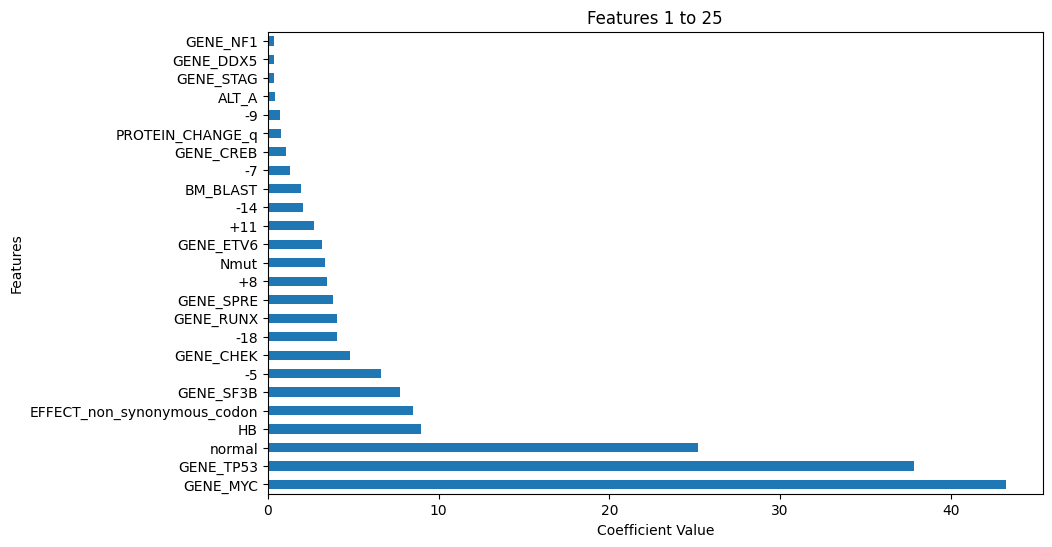

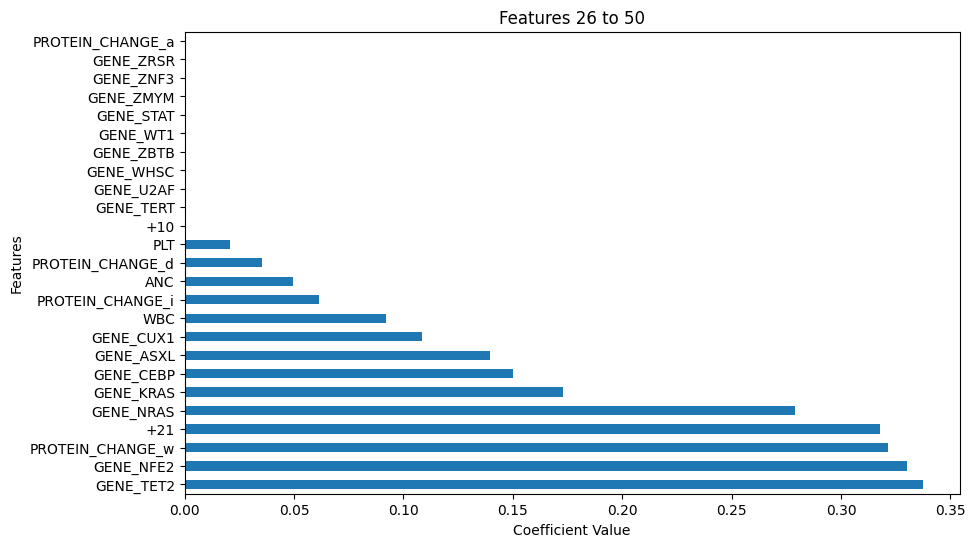

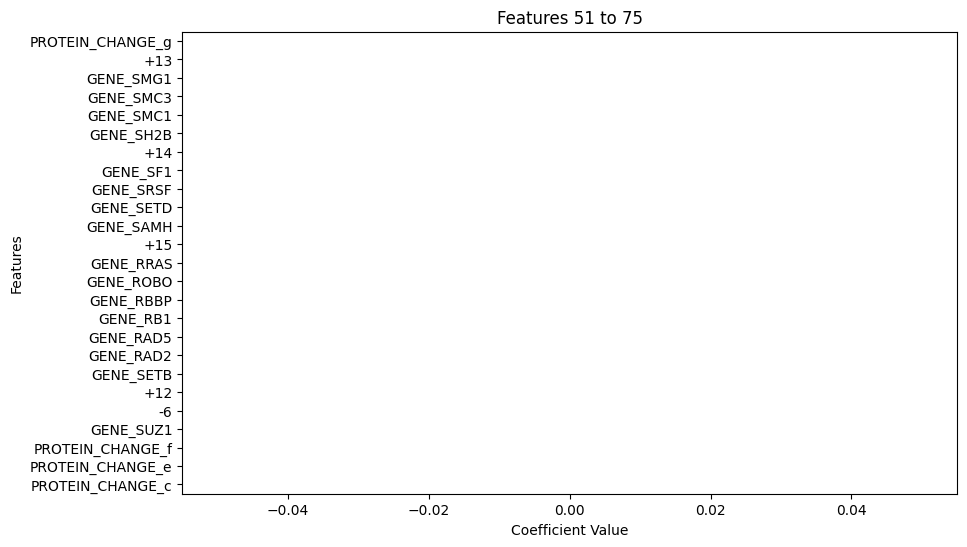

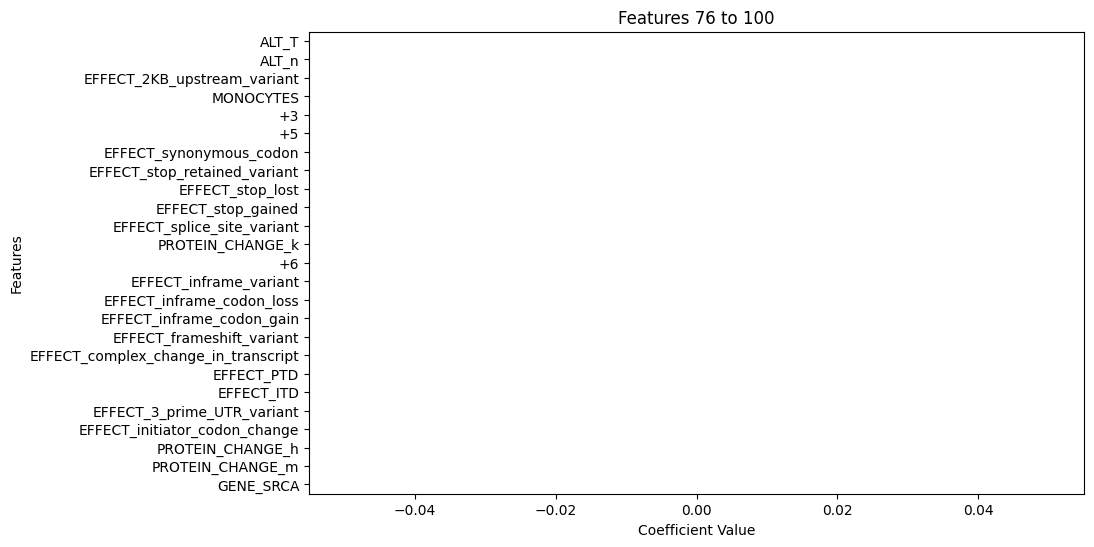

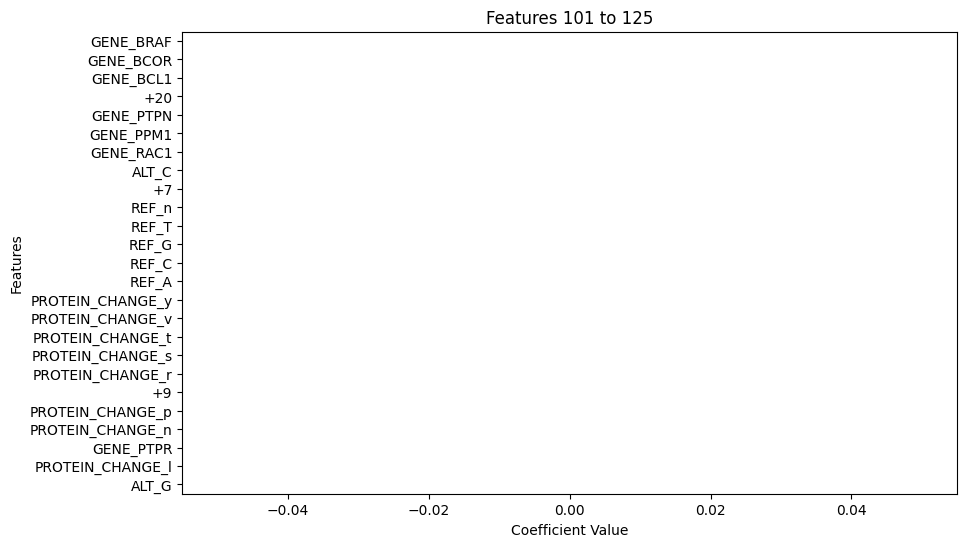

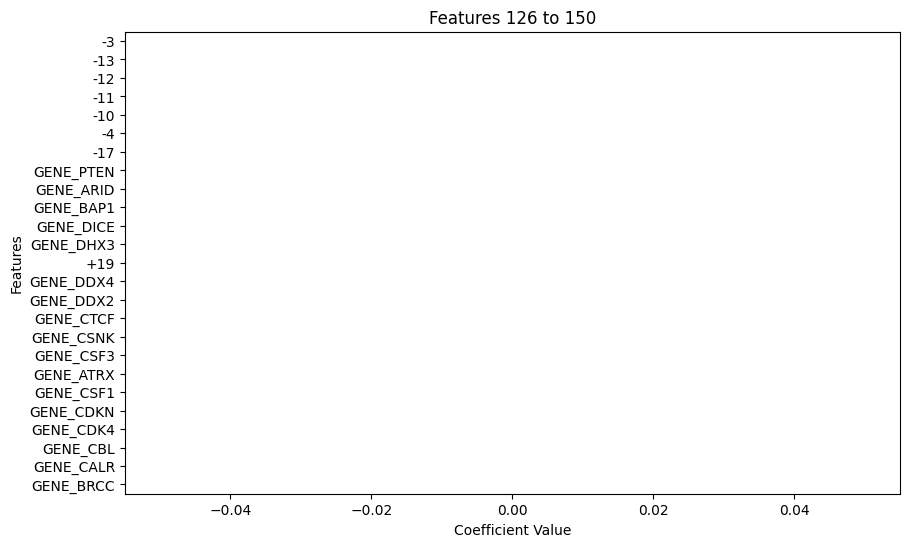

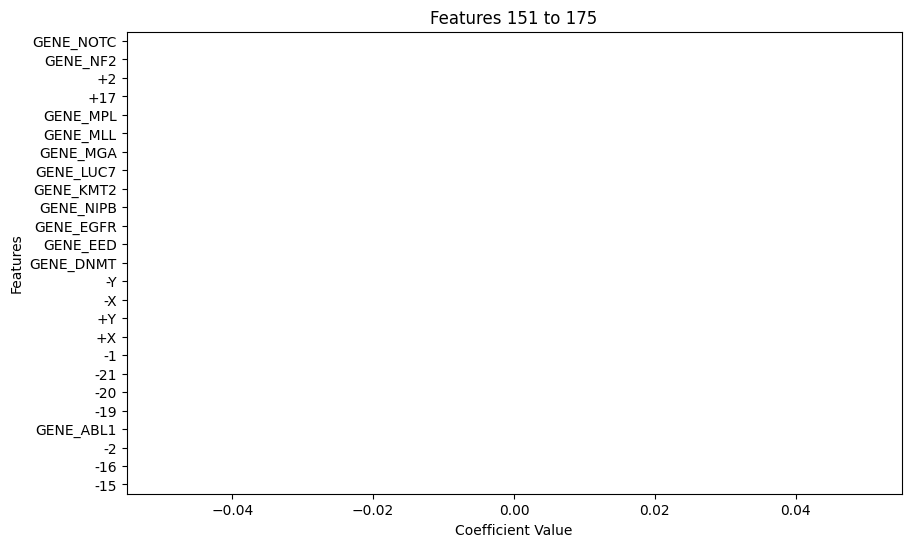

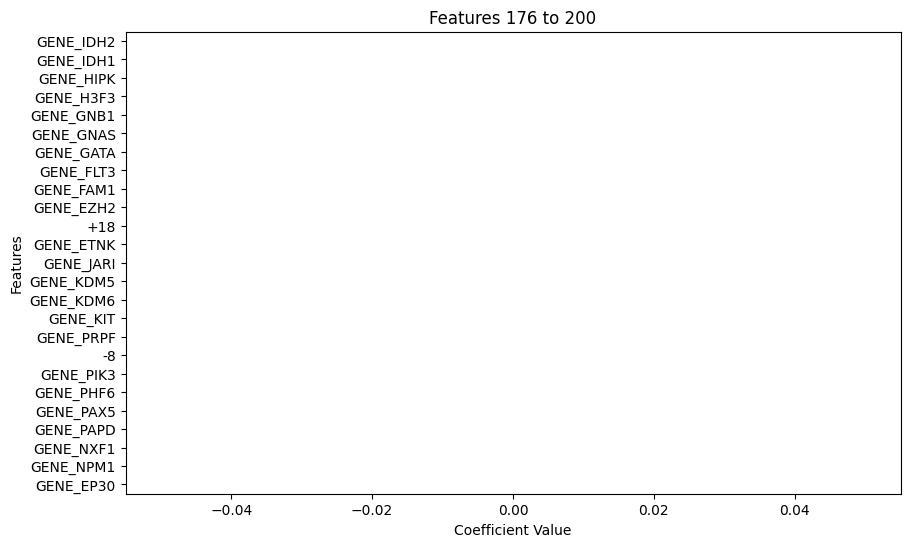

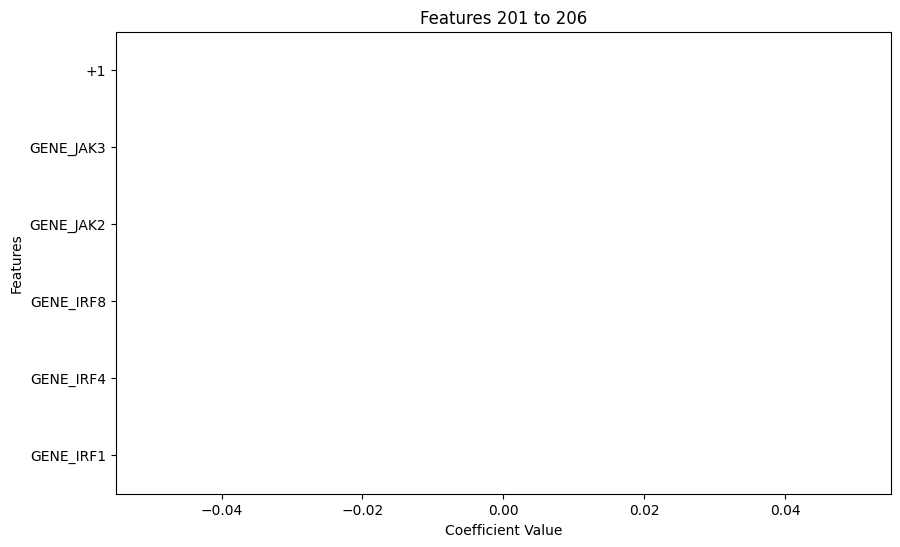

In [27]:
# Print non-zero coefficients number for each feature in chunks of 25
coefs = pd.Series(np.abs(cox.coef_).sum(axis=1), index=X_train.columns)
coefs = coefs.sort_values(ascending=False)
#coefs = coefs[coefs > 0]

plt.figure(figsize=(10, 6))
chunk_size = 25
for i in range(0, len(coefs), chunk_size):
    chunk = coefs.iloc[i:i + chunk_size]
    plt.figure(figsize=(10, 6))
    chunk.plot(kind='barh')
    plt.title(f'Features {i + 1} to {i + len(chunk)}')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.show()

relevant_features = coefs.index.tolist()

5. Using relevant features

In [28]:
features = [feature for feature in features if relevant_features.count(feature) > 0]
print(features)
X_train_relevant = X_train[relevant_features]
X_test_relevant = X_test[relevant_features]
X_eval_relevant = X_eval[relevant_features]

X_train_relevant.head()

['BM_BLAST', 'HB', 'PLT', 'ANC', 'WBC', 'MONOCYTES', 'Nmut']


,GENE_MYC,GENE_TP53,normal,HB,EFFECT_non_synonymous_codon,GENE_SF3B,-5,GENE_CHEK,-18,GENE_RUNX,...,GENE_H3F3,GENE_HIPK,GENE_IDH1,GENE_IDH2,GENE_IRF1,GENE_IRF4,GENE_IRF8,GENE_JAK2,GENE_JAK3,+1
2244,False,False,1.00,11.0,0.795,False,0.0,False,0.0,False,...,False,False,False,False,False,False,False,False,False,0.0
2449,False,False,1.00,7.6,0.356,False,0.0,False,0.0,False,...,False,False,True,True,False,False,False,False,False,0.0
1744,False,False,1.00,12.1,0.240,False,0.0,False,0.0,True,...,False,False,False,False,False,False,False,False,False,0.0
1131,False,True,1.00,11.6,0.499,True,0.0,False,0.0,False,...,False,False,False,False,False,False,False,False,False,0.0
439,False,False,0.41,5.0,0.232,False,0.0,False,0.0,False,...,False,False,False,False,False,False,False,True,False,0.0


In [39]:
cox = CoxnetSurvivalAnalysis(l1_ratio=1, alpha_min_ratio=0.18, max_iter=1000, normalize=True)
cox.fit(X_train_relevant, y_train)

# Evaluate the model using Concordance Index IPC
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train_relevant), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test_relevant), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {100*cox_cindex_train:.3f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {100*cox_cindex_test:.3f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 71.272
Cox Proportional Hazard Model Concordance Index IPCW on test: 71.057


### 4. Prediction

3. Imputer with median strategy

In [46]:
imputer = SimpleImputer(strategy='median')
print(features)
X_train_relevant[features] = imputer.fit_transform(X_train_relevant[features])
X_eval_relevant[features] = imputer.transform(X_eval_relevant[features])
X_eval_relevant = X_eval_relevant.fillna(False)
for col in X_eval_relevant.columns:
    print(col, X_eval_relevant[col].sum())
X_eval_relevant.head(100)

['BM_BLAST', 'HB', 'PLT', 'ANC', 'WBC', 'MONOCYTES', 'Nmut']
GENE_MYC 0
GENE_TP53 307
normal 7752
HB 10624.2
EFFECT_non_synonymous_codon 0.0
GENE_SF3B 92
-5 505
GENE_CHEK 5
-18 364
GENE_RUNX 163
GENE_SPRE 0
+8 501
Nmut 3089.0
GENE_ETV6 24
+11 63
-14 130
BM_BLAST 14438.0
-7 911
GENE_CREB 12
PROTEIN_CHANGE_q 181
-9 89
ALT_A 520
GENE_STAG 80
GENE_DDX5 0
GENE_NF1 32
GENE_TET2 209
GENE_NFE2 4
PROTEIN_CHANGE_w 40
+21 78
GENE_NRAS 58
GENE_KRAS 36
GENE_CEBP 46
GENE_ASXL 158
GENE_CUX1 42
WBC 8389.591
PROTEIN_CHANGE_i 78
ANC 3415.4281309999997
PROTEIN_CHANGE_d 106
PLT 144185.9
+10 54
GENE_TERT 2
GENE_U2AF 111
GENE_WHSC 0
GENE_ZBTB 0
GENE_WT1 46
GENE_STAT 10
GENE_ZMYM 0
GENE_ZNF3 0
GENE_ZRSR 39
PROTEIN_CHANGE_a 75
PROTEIN_CHANGE_c 74
PROTEIN_CHANGE_e 114
PROTEIN_CHANGE_f 35
GENE_SUZ1 1
-6 74
+12 42
GENE_SETB 53
GENE_RAD2 4
GENE_RAD5 0
GENE_RB1 0
GENE_RBBP 0
GENE_ROBO 0
GENE_RRAS 0
+15 59
GENE_SAMH 0
GENE_SETD 0
GENE_SRSF 109
GENE_SF1 0
+14 40
GENE_SH2B 25
GENE_SMC1 3
GENE_SMC3 9
GENE_SMG1 0
+13 7

,GENE_MYC,GENE_TP53,normal,HB,EFFECT_non_synonymous_codon,GENE_SF3B,-5,GENE_CHEK,-18,GENE_RUNX,...,GENE_H3F3,GENE_HIPK,GENE_IDH1,GENE_IDH2,GENE_IRF1,GENE_IRF4,GENE_IRF8,GENE_JAK2,GENE_JAK3,+1
0,False,False,0,7.6,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
1,False,False,20,10.0,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
2,False,False,0,12.3,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
3,False,False,0,8.0,0.0,False,0,False,0,True,...,False,False,False,False,False,False,False,False,False,0
4,False,False,0,8.6,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,False,False,15,9.0,False,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
96,False,False,0,7.9,0.0,True,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
97,False,False,8,9.6,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0
98,False,True,0,8.6,0.0,False,0,False,0,False,...,False,False,False,False,False,False,False,False,False,0


In [41]:
prediction_on_test_set = cox.predict(X_eval_relevant)
prediction_on_test_set

array([ 2.17048807, -7.09225717, -0.0758959 , ...,  0.54338256,
        0.06812093,  0.56704207])

In [42]:
submission = pd.Series(prediction_on_test_set, index=df_eval['ID'], name='risk_score')

In [43]:
submission.to_csv('./submission/cox_ridge_submission.csv')

In [44]:
submission.head()

ID
KYW1    2.170488
KYW2   -7.092257
KYW3   -0.075896
KYW4    2.001147
KYW5    1.386909
Name: risk_score, dtype: float64